# Lebesgue Spaces Demo

## Table of Contents

1. [Creating Lebesgue Spaces](#1-creating-lebesgue-spaces)
2. [Basis Functions](#2-basis-functions)
3. [Creating Functions in the Space](#3-creating-functions-in-the-space)
4. [L² Inner Product and Norm](#4-l²-inner-product-and-norm)
5. [The Gram Matrix (Metric Tensor)](#5-the-gram-matrix-metric-tensor)
6. [Projection onto the Finite-Dimensional Subspace](#6-projection-onto-the-finite-dimensional-subspace)
7. [Coefficient Extraction](#7-coefficient-extraction)
8. [Weighted L² Spaces](#8-weighted-l²-spaces)
9. [Summary: Mathematical vs. Computational Reality](#9-summary-mathematical-vs-computational-reality)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import from intervalinf
from intervalinf import IntervalDomain, Function
from intervalinf.spaces import Lebesgue, WeightedLebesgue

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Creating Lebesgue Spaces

### What is a Lebesgue Space?

The **Lebesgue space** $L^2(\Omega)$ is the space of all square-integrable functions on a domain $\Omega$. Mathematically, a function $f: \Omega \to \mathbb{R}$ belongs to $L^2(\Omega)$ if:

$$
\int_\Omega |f(x)|^2 \, dx < \infty
$$

This is a **Hilbert space** with the inner product:

$$
\langle f, g \rangle = \int_\Omega f(x) g(x) \, dx
$$

and induced norm:

$$
\|f\|_{L^2} = \sqrt{\langle f, f \rangle} = \left( \int_\Omega |f(x)|^2 \, dx \right)^{1/2}
$$

### Why L²?

- **Completeness**: Every Cauchy sequence converges (unlike, say, continuous functions with $L^2$ norm)
- **Inner product structure**: Enables geometry (orthogonality, projection, angles between functions)
- **Physical interpretation**: For probability densities, the norm represents "total probability mass"
- **Spectral methods**: Natural setting for Fourier analysis and eigenfunction expansions

### Two Modes of Working with L² Spaces

**IMPORTANT**: In `intervalinf`, you have **two complementary approaches**:

1. **Infinite-dimensional (function-based)**: Work with actual functions via callables
   - Create `Lebesgue(0, domain, basis=None)` - no basis needed!
   - Functions are represented by evaluation rules: `f(x)` computes the value
   - This is the **true infinite-dimensional** $L^2$ space
   - Inner products and norms computed via numerical integration
   - Ideal for general function manipulation, non-parametric problems


2. **Finite-dimensional (basis-based)**: Use basis function expansions
   - Create `Lebesgue(dim, domain, basis='fourier')` with a specific basis
   - Functions represented as coefficient vectors: $f = \sum_{i=0}^{n-1} c_i \varphi_i$
   - Faster computations using linear algebra
   - Ideal for spectral methods, Galerkin approximations, parametric problems

**You choose the mode that fits your problem!** Basis functions are **optional**, not required.

### Core API Usage:

In [2]:
# Create a domain
domain = IntervalDomain(0, 1, boundary_type='closed')

# Mode 1: Infinite-dimensional (no basis required!)
space_infinite = Lebesgue(0, domain, basis=None)
print(f"Infinite-dimensional space: dim={space_infinite.dim}")
print(f"Has basis: {space_infinite._basis_type != 'none'}")
print()

# Mode 2: Finite-dimensional with Fourier basis
space_finite = Lebesgue(10, domain, basis='fourier')
print(f"Finite-dimensional space: dim={space_finite.dim}")
print(f"Has basis: {space_finite._basis_type != 'none'}")

# Both are valid L² spaces on the same domain!

Infinite-dimensional space: dim=0
Has basis: False

Finite-dimensional space: dim=10
Has basis: True


### Different Basis Types:

In [3]:
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

# Built-in basis types
fourier_space = Lebesgue(20, domain, basis='fourier')
sine_space = Lebesgue(15, domain, basis='sine')
cosine_space = Lebesgue(15, domain, basis='cosine')

# Custom basis from list of callables
custom_basis = [
    lambda x: np.ones_like(x),        # constant
    lambda x: x,                      # linear
    lambda x: x**2,                   # quadratic
    lambda x: np.sin(x),              # sine
    lambda x: np.cos(x),              # cosine
]
custom_space = Lebesgue(5, domain, basis=custom_basis)

print("Created Lebesgue Spaces:")
print("="*60)
for name, sp in [('Fourier', fourier_space),
                  ('Sine', sine_space),
                  ('Cosine', cosine_space),
                  ('Custom', custom_space)]:
    print(f"{name:10s}: dim={sp.dim:2d}, domain={sp.function_domain}")

Created Lebesgue Spaces:
Fourier   : dim=20, domain=[0.0, 6.283185307179586]
Sine      : dim=15, domain=[0.0, 6.283185307179586]
Cosine    : dim=15, domain=[0.0, 6.283185307179586]
Custom    : dim= 5, domain=[0.0, 6.283185307179586]


## 2. Basis Functions

### Mathematical Background: Basis Functions in L²

A **basis** for a finite-dimensional subspace $V_n \subset L^2(\Omega)$ is a set of linearly independent functions $\{\varphi_0, \varphi_1, \ldots, \varphi_{n-1}\}$ such that every function in $V_n$ can be written as:

$$
f = \sum_{i=0}^{n-1} c_i \varphi_i
$$

for unique coefficients $c_i \in \mathbb{R}$.

### Orthonormal Bases

A basis is **orthonormal** if:

$$
\langle \varphi_i, \varphi_j \rangle = \delta_{ij} = \begin{cases} 1 & \text{if } i = j \\ 0 & \text{if } i \neq j \end{cases}
$$

Orthonormal bases are particularly convenient because coefficients can be computed as:

$$
c_i = \langle f, \varphi_i \rangle
$$

### Common Bases

1. **Fourier basis** (on $[0, 2\pi]$): $\{1, \sin(x), \cos(x), \sin(2x), \cos(2x), \ldots\}$
2. **Sine basis**: $\{\sin(kx)\}_{k=1}^n$ - useful for problems with zero boundary conditions
3. **Cosine basis**: $\{\cos(kx)\}_{k=0}^{n-1}$ - useful for Neumann boundary conditions
4. **Polynomial basis**: $\{1, x, x^2, \ldots, x^{n-1}\}$ - simple but not orthonormal

### Core API Usage:

In [4]:
# Get individual basis functions
domain = IntervalDomain(0, 2*np.pi)
space = Lebesgue(10, domain, basis='fourier')

# Access basis function by index
phi_0 = space.get_basis_function(0)
phi_3 = space.get_basis_function(3)

# Evaluate basis function
x = np.linspace(0, 2*np.pi, 100)
y = phi_0(x)

### Visualizing Basis Functions:

Fourier Basis Functions in L²([0, 2π])
Space dimension: 8



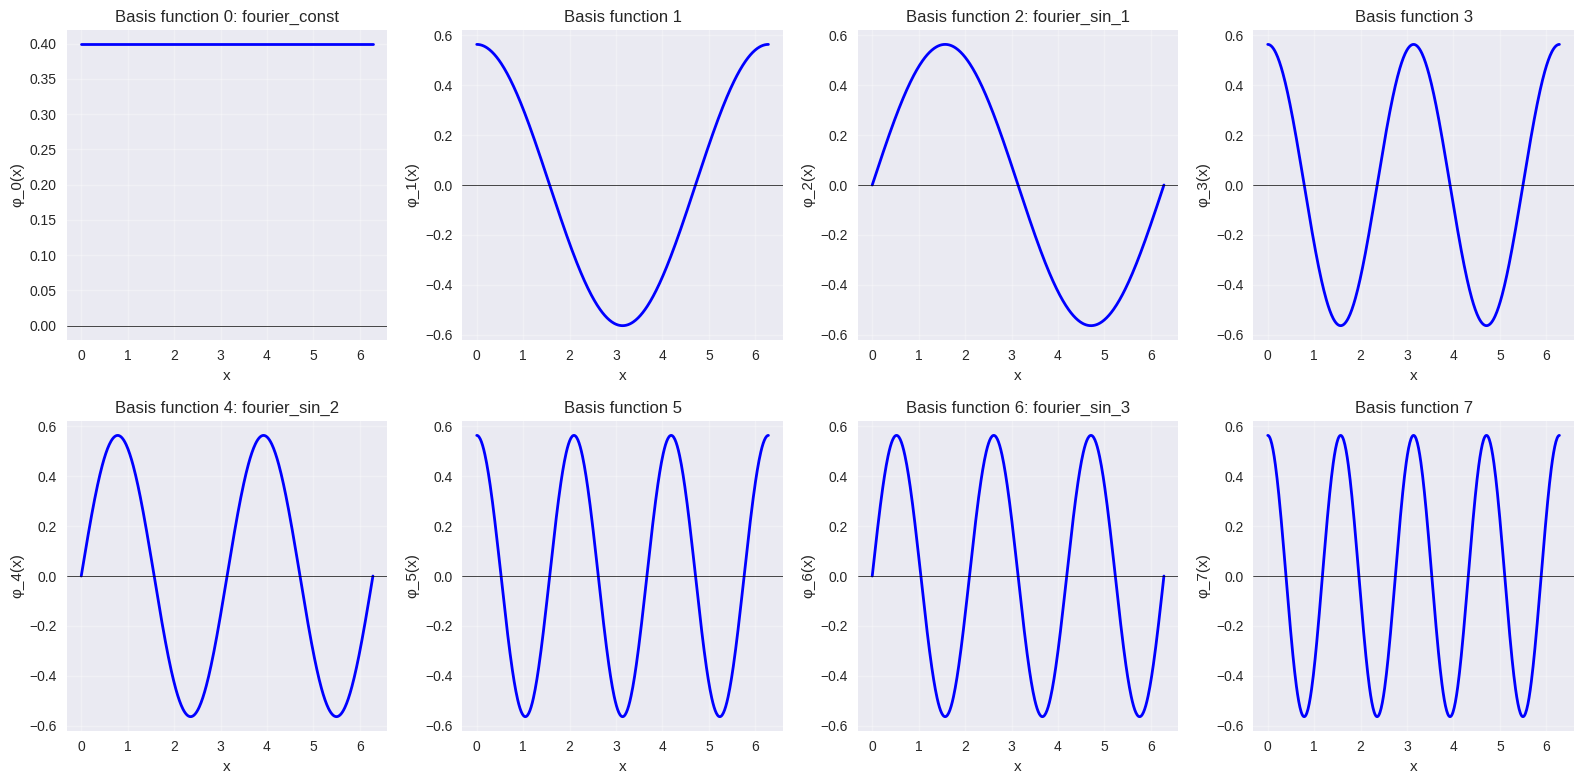

✓ Fourier basis consists of sines and cosines
✓ These form an orthogonal system in L²


In [5]:
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
space = Lebesgue(8, domain, basis='fourier')

x = np.linspace(0, 2*np.pi, 500)

print(f"Fourier Basis Functions in L²([0, 2π])")
print(f"Space dimension: {space.dim}")
print()

# Plot first 8 basis functions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, space.dim)):
    phi_i = space.get_basis_function(i)
    y = phi_i(x)

    axes[i].plot(x, y, 'b-', linewidth=2)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(f'φ_{i}(x)')
    axes[i].set_title(f'Basis function {i}' + (f': {phi_i.name}' if phi_i.name else ''))
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("✓ Fourier basis consists of sines and cosines")
print("✓ These form an orthogonal system in L²")

## 3. Creating Functions in the Space

### Mathematical Background: Function Representation

Functions in $L^2$ can be represented in **two fundamentally different ways**:

#### 1. Function-based (Infinite-dimensional)

Represent functions via **evaluation rules** (callables). The function $f$ is defined by how it maps $x \mapsto f(x)$:
- No basis required
- Can represent any function in $L^2(\Omega)$
- Inner products computed via numerical integration: $\langle f, g \rangle = \int f(x)g(x)dx$
- This is the **full infinite-dimensional** $L^2$ space

#### 2. Basis-based (Finite-dimensional)

**When a basis is provided**, functions in the finite-dimensional subspace $V_n \subset L^2$ have a **unique representation** as:

$$
f = \sum_{i=0}^{n-1} c_i \varphi_i
$$

where the **coefficient vector** $\mathbf{c} = [c_0, c_1, \ldots, c_{n-1}]^T \in \mathbb{R}^n$ completely determines the function.
- Inner products computed via linear algebra: $\langle f, g \rangle = \mathbf{c}^T G \mathbf{d}$
- Fast computations using matrix operations
- Restricts to $V_n \subset L^2$, a finite-dimensional subspace

### Ways to Create Functions (Basis Mode)

**When working with a basis**, you can create functions in two ways:

1. **From coefficients** (exact, finite-dimensional): Directly specify $\mathbf{c}$
   - This gives an exact representation in $V_n$
   - Common in spectral methods, Galerkin methods

2. **From a general function** (requires projection): Given any $g \in L^2(\Omega)$
   - Compute the **L² projection** $\Pi_{V_n} g$, the best approximation in $V_n$
   - This minimizes $\|g - \Pi_{V_n} g\|_{L^2}$ over all functions in $V_n$
   - For orthonormal bases: $c_i = \langle g, \varphi_i \rangle$

**Without a basis**: Simply create functions using callables (see Functions Demo notebook)

### Core API Usage:

In [6]:
domain = IntervalDomain(0, 1)

# === WITHOUT BASIS (Infinite-dimensional mode) ===
space_no_basis = Lebesgue(0, domain, basis=None)

# Create function directly from callable - no projection needed!
f_infinite = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")
print(f"Function in infinite-dimensional L²: {f_infinite.name}")
print(f"  Has coefficients: {f_infinite.coefficients is not None}")
print(f"  Can evaluate: f(0.5) = {f_infinite(0.5):.4f}")
print()

# === WITH BASIS (Finite-dimensional mode) ===
space_with_basis = Lebesgue(10, domain, basis='fourier')

# Method 1: From coefficients (only works when basis exists)
coeffs = np.random.randn(10)
f_from_coeffs = space_with_basis.from_components(coeffs)
print(f"Function from coefficients: {f_from_coeffs.name or 'unnamed'}")
print(f"  Has coefficients: {f_from_coeffs.coefficients is not None}")
print()

# Method 2: Project a callable onto the finite-dimensional subspace
g_func = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x))
g_projected = space_with_basis.project(g_func)
print(f"Projected function: {g_projected.name or g_func.name}")
print(f"  Original had no coefficients: {g_func.coefficients is None}")
print(f"  Projected has coefficients: {g_projected.coefficients is not None}")

Function in infinite-dimensional L²: sin(πx)
  Has coefficients: False
  Can evaluate: f(0.5) = 1.0000

Function from coefficients: unnamed
  Has coefficients: True

Projected function: None
  Original had no coefficients: True
  Projected has coefficients: True


### Detailed Examples:

Creating Functions in L²([0, 2π]):
Random function: unnamed
  Has coefficients: True
  Coefficient shape: (20,)

Specific modes function:
  Non-zero coefficients: 3

Projected function: sin(x) + 0.5sin(3x)
  Original was standalone: True
  Projected is attached: True


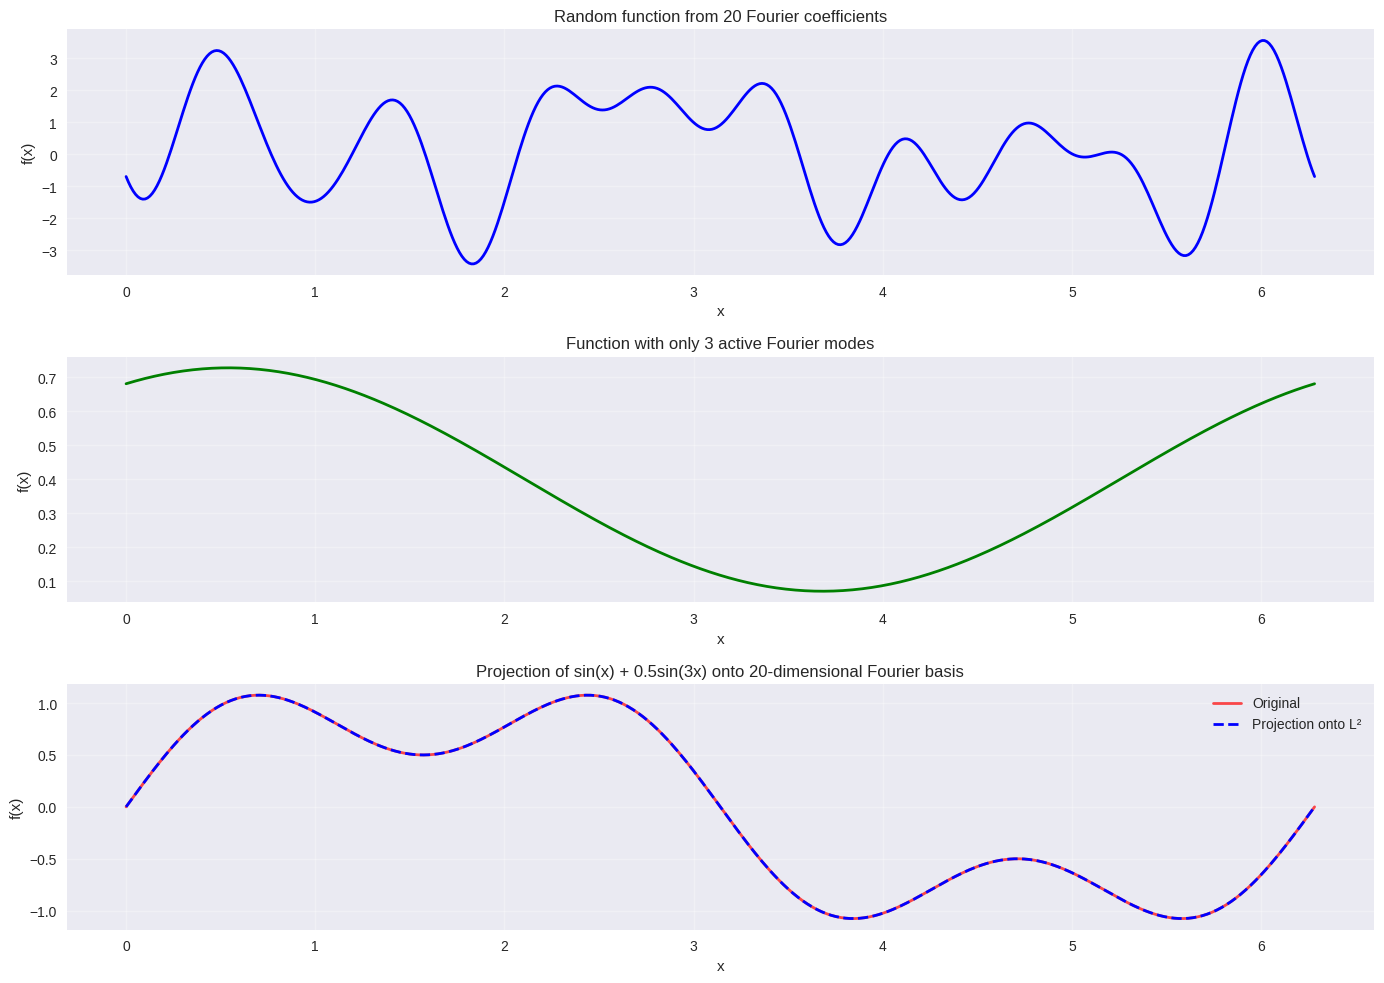


Max pointwise error in projection: 6.29e-08

✓ Functions can be created from coefficients or projected from callables
✓ Projection finds best L² approximation in finite-dimensional subspace


In [7]:
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
space = Lebesgue(20, domain, basis='fourier')

print("Creating Functions in L²([0, 2π]):")
print("="*60)

# Example 1: From random coefficients
np.random.seed(42)
random_coeffs = np.random.randn(20)
f_random = space.from_components(random_coeffs)
print(f"Random function: {f_random.name or 'unnamed'}")
print(f"  Has coefficients: {f_random.coefficients is not None}")
print(f"  Coefficient shape: {f_random.coefficients.shape if f_random.coefficients is not None else None}")

# Example 2: From specific coefficients (select a few modes)
specific_coeffs = np.zeros(20)
specific_coeffs[0] = 1.0   # DC component
specific_coeffs[1] = 0.5   # First sine mode
specific_coeffs[2] = 0.3   # First cosine mode
f_specific = space.from_components(specific_coeffs)
print(f"\nSpecific modes function:")
print(f"  Non-zero coefficients: {np.sum(specific_coeffs != 0)}")

# Example 3: Project a callable function
def target_func(x):
    return np.sin(x) + 0.5 * np.sin(3*x)

g_standalone = Function(domain, evaluate_callable=target_func, name="sin(x) + 0.5sin(3x)")
g_projected = space.project(g_standalone)
print(f"\nProjected function: {g_projected.name or g_standalone.name}")
print(f"  Original was standalone: {not g_standalone.is_attached}")
print(f"  Projected is attached: {g_projected.is_attached}")

# Visualize
x = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(14, 10))

# Plot 1: Random function
plt.subplot(3, 1, 1)
y = f_random(x)
plt.plot(x, y, 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Random function from 20 Fourier coefficients')
plt.grid(True, alpha=0.3)

# Plot 2: Specific modes
plt.subplot(3, 1, 2)
y = f_specific(x)
plt.plot(x, y, 'g-', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function with only 3 active Fourier modes')
plt.grid(True, alpha=0.3)

# Plot 3: Projected vs original
plt.subplot(3, 1, 3)
y_orig = g_standalone(x)
y_proj = g_projected(x)
plt.plot(x, y_orig, 'r-', linewidth=2, label='Original', alpha=0.7)
plt.plot(x, y_proj, 'b--', linewidth=2, label='Projection onto L²')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Projection of sin(x) + 0.5sin(3x) onto 20-dimensional Fourier basis')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check approximation error
error = np.max(np.abs(y_orig - y_proj))
print(f"\nMax pointwise error in projection: {error:.2e}")
print("\n✓ Functions can be created from coefficients or projected from callables")
print("✓ Projection finds best L² approximation in finite-dimensional subspace")

## 4. L² Inner Product and Norm

### Mathematical Background: The Inner Product

The **L² inner product** on $L^2(\Omega)$ is defined as:

$$
\langle f, g \rangle_{L^2} = \int_\Omega f(x) g(x) \, dx
$$

This satisfies the axioms of an inner product:

1. **Linearity**: $\langle \alpha f + \beta g, h \rangle = \alpha \langle f, h \rangle + \beta \langle g, h \rangle$
2. **Symmetry**: $\langle f, g \rangle = \langle g, f \rangle$ (for real-valued functions)
3. **Positive definiteness**: $\langle f, f \rangle \geq 0$ with equality iff $f = 0$ (almost everywhere)

### The Induced Norm

The inner product induces a **norm** (measure of "size"):

$$
\|f\|_{L^2} = \sqrt{\langle f, f \rangle} = \left( \int_\Omega f(x)^2 \, dx \right)^{1/2}
$$

which satisfies:

1. **Positive definiteness**: $\|f\| \geq 0$ with equality iff $f = 0$
2. **Homogeneity**: $\|\alpha f\| = |\alpha| \|f\|$
3. **Triangle inequality**: $\|f + g\| \leq \|f\| + \|g\|$

### Important Inequalities

**Cauchy-Schwarz inequality**: For any $f, g \in L^2$:

$$
|\langle f, g \rangle| \leq \|f\| \cdot \|g\|
$$

with equality iff $f$ and $g$ are linearly dependent.

### Geometric Interpretation

The inner product gives $L^2$ a **geometric structure**:
- **Orthogonality**: $f \perp g$ means $\langle f, g \rangle = 0$
- **Distance**: $d(f, g) = \|f - g\|_{L^2}$
- **Angle**: $\cos(\theta) = \frac{\langle f, g \rangle}{\|f\| \|g\|}$

### Core API Usage:

In [8]:
# Create functions in the space
domain = IntervalDomain(0, 1)
space = Lebesgue(20, domain, basis='fourier')

f = space.from_components(np.random.randn(20))
g = space.from_components(np.random.randn(20))

# L² inner product: ⟨f, g⟩ = ∫ f(x)g(x) dx
inner_prod = space.inner_product(f, g)

# L² norm: ‖f‖ = √⟨f, f⟩
norm_f = space.norm(f)

# Distance: ‖f - g‖
distance = space.distance(f, g)

### Detailed Examples and Properties:

In [9]:
domain = IntervalDomain(0, np.pi, boundary_type='closed')
space = Lebesgue(15, domain, basis='sine')

# Create test functions
np.random.seed(42)
coeffs_f = np.random.randn(15)
coeffs_g = np.random.randn(15)
coeffs_h = 2 * coeffs_f + 0.5 * coeffs_g  # Linear combination

f = space.from_components(coeffs_f)
g = space.from_components(coeffs_g)
h = space.from_components(coeffs_h)

print("L² Inner Product and Norm Properties:")
print("="*60)

# Basic computations
inner_fg = space.inner_product(f, g)
inner_gf = space.inner_product(g, f)
norm_f = space.norm(f)
norm_g = space.norm(g)

print(f"⟨f, g⟩ = {inner_fg:.6f}")
print(f"⟨g, f⟩ = {inner_gf:.6f}")
print(f"Symmetry check: |⟨f,g⟩ - ⟨g,f⟩| = {abs(inner_fg - inner_gf):.2e}")
print()

print(f"‖f‖_L² = {norm_f:.6f}")
print(f"‖g‖_L² = {norm_g:.6f}")
print(f"⟨f, f⟩ = {space.inner_product(f, f):.6f}")
print(f"‖f‖² = {norm_f**2:.6f}")
print()

# Linearity in first argument
a, b = 2.0, 0.5
inner_direct = space.inner_product(h, g)  # ⟨2f + 0.5g, g⟩
inner_expanded = a * space.inner_product(f, g) + b * space.inner_product(g, g)
print(f"Linearity check: ⟨{a}f + {b}g, g⟩")
print(f"  Direct:   {inner_direct:.6f}")
print(f"  Expanded: {inner_expanded:.6f}")
print(f"  Difference: {abs(inner_direct - inner_expanded):.2e}")
print()

# Cauchy-Schwarz inequality: |⟨f, g⟩| ≤ ‖f‖ ‖g‖
cs_left = abs(inner_fg)
cs_right = norm_f * norm_g
print(f"Cauchy-Schwarz: |⟨f, g⟩| ≤ ‖f‖ ‖g‖")
print(f"  |⟨f, g⟩| = {cs_left:.6f}")
print(f"  ‖f‖ ‖g‖ = {cs_right:.6f}")
print(f"  Satisfied: {cs_left <= cs_right + 1e-10}")
print()

# Distance
dist_fg = space.distance(f, g)
diff = space.add(f, space.multiply(-1, g))  # f - g
norm_diff = space.norm(diff)
print(f"Distance: ‖f - g‖ = {dist_fg:.6f}")
print(f"Via norm: ‖f - g‖ = {norm_diff:.6f}")
print(f"Consistency: {abs(dist_fg - norm_diff):.2e}")

print("\n✓ All L² properties verified!")
print("✓ Inner product is symmetric and bilinear")
print("✓ Norm satisfies all required properties")
print("✓ Cauchy-Schwarz inequality holds")

L² Inner Product and Norm Properties:
⟨f, g⟩ = 0.965550
⟨g, f⟩ = 0.965550
Symmetry check: |⟨f,g⟩ - ⟨g,f⟩| = 0.00e+00

‖f‖_L² = 3.720006
‖g‖_L² = 3.273204
⟨f, f⟩ = 13.838446
‖f‖² = 13.838446

Linearity check: ⟨2.0f + 0.5g, g⟩
  Direct:   7.288034
  Expanded: 7.288034
  Difference: 8.88e-16

Cauchy-Schwarz: |⟨f, g⟩| ≤ ‖f‖ ‖g‖
  |⟨f, g⟩| = 0.965550
  ‖f‖ ‖g‖ = 12.176341
  Satisfied: True

Distance: ‖f - g‖ = 4.756176
Via norm: ‖f - g‖ = 4.756176
Consistency: 0.00e+00

✓ All L² properties verified!
✓ Inner product is symmetric and bilinear
✓ Norm satisfies all required properties
✓ Cauchy-Schwarz inequality holds


## 5. The Gram Matrix (Metric Tensor)

### Mathematical Background

The **Gram matrix** (also called the **metric tensor** or **mass matrix**) is defined as:

$$
G_{ij} = \langle \varphi_i, \varphi_j \rangle = \int_\Omega \varphi_i(x) \varphi_j(x) \, dx
$$

This $n \times n$ matrix encodes the **geometry** of our finite-dimensional subspace.

### Why is the Gram Matrix Important?

1. **Computing inner products**: For $f = \sum_i c_i \varphi_i$ and $g = \sum_j d_j \varphi_j$:
   $$
   \langle f, g \rangle = \sum_{i,j} c_i d_j \langle \varphi_i, \varphi_j \rangle = \mathbf{c}^T G \mathbf{d}
   $$

2. **Computing norms**: 
   $$
   \|f\|^2 = \langle f, f \rangle = \mathbf{c}^T G \mathbf{c}
   $$

3. **Basis quality**: 
   - If $G = I$ (identity), the basis is **orthonormal** - ideal!
   - If $G$ is diagonal, the basis is **orthogonal**
   - If $G$ is ill-conditioned, the basis is nearly linearly dependent - numerical problems ahead!

### Properties of the Gram Matrix

- **Symmetric**: $G_{ij} = G_{ji}$
- **Positive definite**: All eigenvalues are positive (if basis is linearly independent)
- **For orthonormal bases**: $G = I$ (identity matrix)

### Core API Usage:

In [10]:
# Access the Gram matrix
domain = IntervalDomain(0, 1)
space = Lebesgue(10, domain, basis='fourier')

# Gram matrix G[i,j] = ⟨φᵢ, φⱼ⟩
G = space.metric

# For orthonormal bases, G ≈ I (identity matrix)

### Visualizing the Gram Matrix:

Gram Matrices for Different Bases:

Fourier basis:
  Gram matrix shape: (10, 10)
  Diagonal (first 5): [1. 1. 1. 1. 1.]
  Off-diagonal max: 7.54e-09
  Distance from identity: 7.54e-09

Sine basis:
  Gram matrix shape: (10, 10)
  Diagonal (first 5): [1. 1. 1. 1. 1.]
  Off-diagonal max: 5.31e-10
  Distance from identity: 6.52e-10


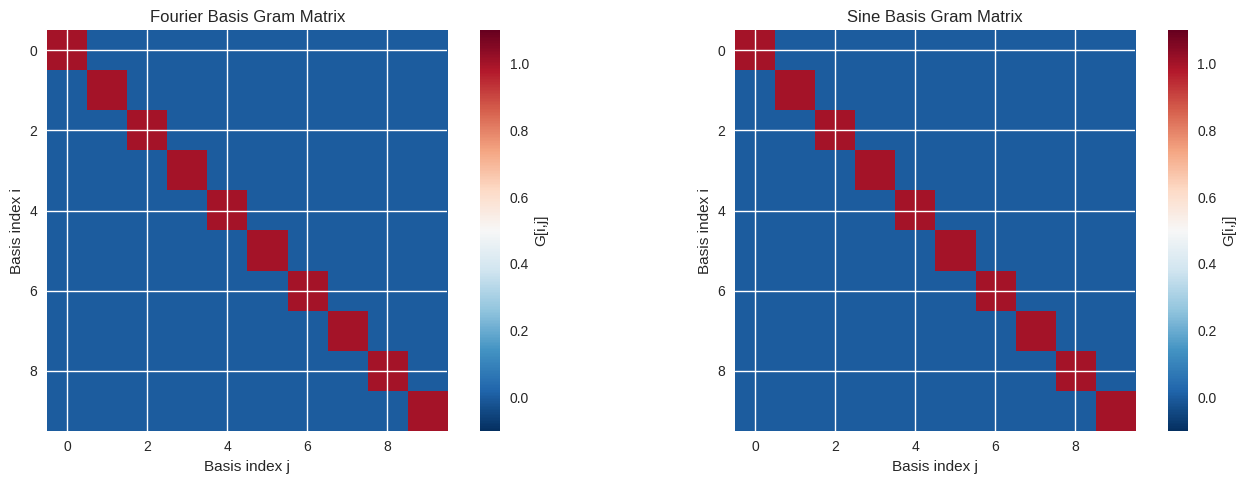


✓ Fourier and sine bases are (approximately) orthonormal
✓ Gram matrix ≈ Identity for orthonormal bases
✓ Off-diagonal elements indicate non-orthogonality


In [11]:
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

# Compare different bases
spaces = {
    'Fourier': Lebesgue(10, domain, basis='fourier'),
    'Sine': Lebesgue(10, domain, basis='sine'),
}

print("Gram Matrices for Different Bases:")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, space) in enumerate(spaces.items()):
    G = space.metric

    print(f"\n{name} basis:")
    print(f"  Gram matrix shape: {G.shape}")
    print(f"  Diagonal (first 5): {np.diag(G)[:5]}")
    print(f"  Off-diagonal max: {np.max(np.abs(G - np.diag(np.diag(G)))):.2e}")

    # Check if approximately orthonormal
    identity_diff = np.max(np.abs(G - np.eye(space.dim)))
    print(f"  Distance from identity: {identity_diff:.2e}")

    # Plot
    ax = axes[idx]
    im = ax.imshow(G, cmap='RdBu_r', vmin=-0.1, vmax=1.1)
    ax.set_title(f'{name} Basis Gram Matrix')
    ax.set_xlabel('Basis index j')
    ax.set_ylabel('Basis index i')
    plt.colorbar(im, ax=ax, label='G[i,j]')

plt.tight_layout()
plt.show()

print("\n✓ Fourier and sine bases are (approximately) orthonormal")
print("✓ Gram matrix ≈ Identity for orthonormal bases")
print("✓ Off-diagonal elements indicate non-orthogonality")

## 6. Projection onto the Finite-Dimensional Subspace

### Mathematical Background: Orthogonal Projection

Given a function $f \in L^2(\Omega)$ and a finite-dimensional subspace $V_n = \text{span}\{\varphi_0, \ldots, \varphi_{n-1}\}$, the **orthogonal projection** $\Pi_{V_n} f$ is the unique function in $V_n$ that minimizes the $L^2$ distance:

$$
\Pi_{V_n} f = \arg\min_{g \in V_n} \|f - g\|_{L^2}
$$

### The Projection Theorem

The projection $\Pi_{V_n} f$ satisfies the **orthogonality condition**:

$$
f - \Pi_{V_n} f \perp V_n
$$

meaning $\langle f - \Pi_{V_n} f, \varphi_i \rangle = 0$ for all basis functions $\varphi_i$.

### Computing the Projection

Writing $\Pi_{V_n} f = \sum_{i=0}^{n-1} c_i \varphi_i$, the orthogonality condition gives:

$$
\sum_{j=0}^{n-1} c_j \langle \varphi_j, \varphi_i \rangle = \langle f, \varphi_i \rangle \quad \text{for } i = 0, \ldots, n-1
$$

In matrix form:

$$
G \mathbf{c} = \mathbf{b}
$$

where $G_{ij} = \langle \varphi_i, \varphi_j \rangle$ (Gram matrix) and $b_i = \langle f, \varphi_i \rangle$.

**For orthonormal bases**: $G = I$, so $c_i = \langle f, \varphi_i \rangle$ (simple!)

### Approximation Quality

The projection error satisfies **Bessel's inequality**:

$$
\|f - \Pi_{V_n} f\|^2 = \|f\|^2 - \sum_{i=0}^{n-1} |c_i|^2
$$

As $n \to \infty$ (with complete basis), we get **Parseval's identity**: $\|f\|^2 = \sum_{i=0}^\infty |c_i|^2$

### Core API Usage:

In [12]:
# Project a function onto the space
domain = IntervalDomain(0, 1)
space = Lebesgue(20, domain, basis='fourier')

# Create standalone function
f_original = Function(domain, evaluate_callable=lambda x: np.sin(5*np.pi*x))

# Project onto finite-dimensional subspace
f_projected = space.project(f_original)

# f_projected minimizes ‖f_original - f_projected‖_L²

### Projection Quality vs. Dimension:

Projection Quality vs. Dimension:
Dimension  5: L² error = 1.092614
Dimension 10: L² error = 0.639067
Dimension 20: L² error = 0.000000
Dimension 40: L² error = 0.000001


/tmp/ipykernel_6761/2716098902.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_error = np.sqrt(np.trapz((y_true - y_proj)**2, x))


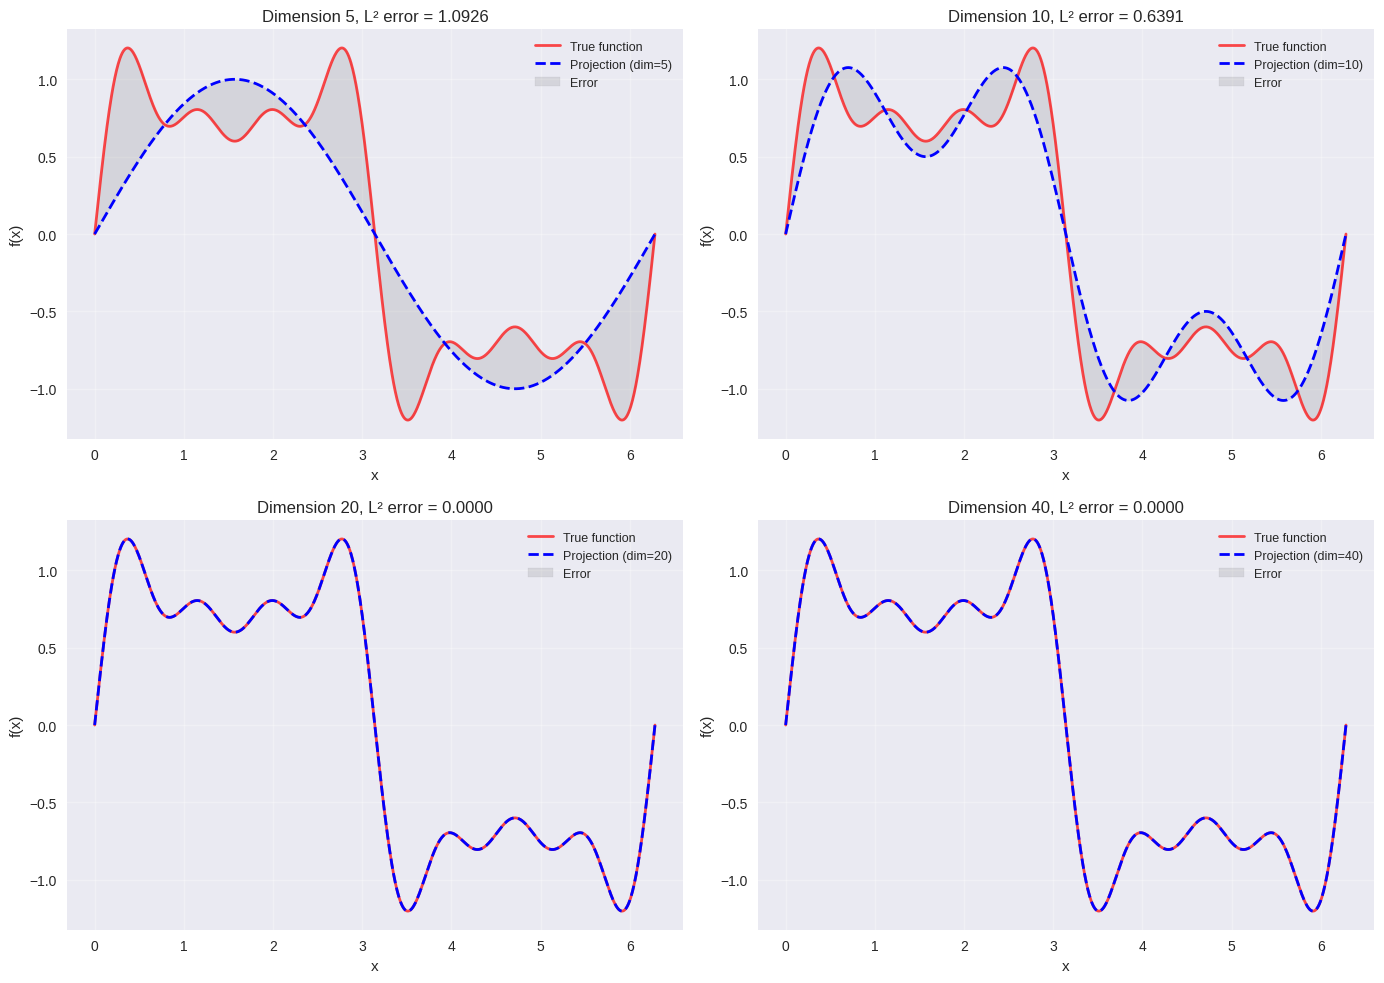

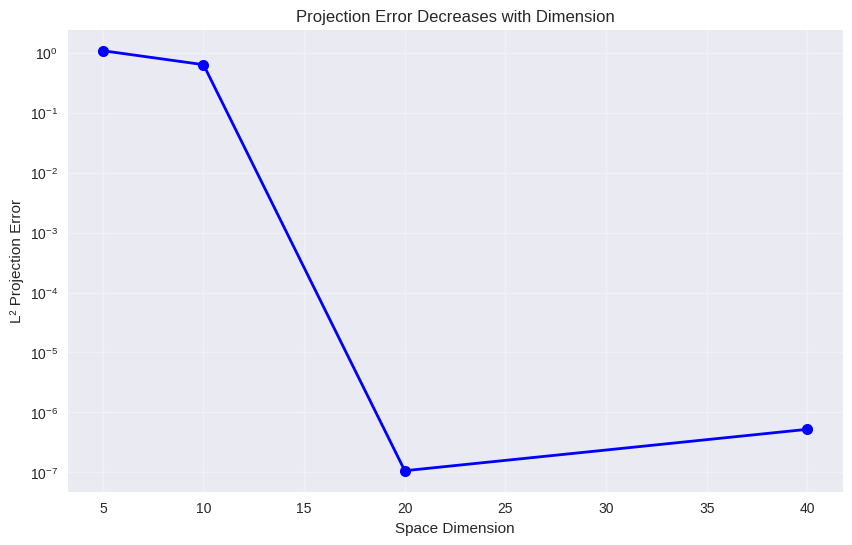


✓ Higher dimension → better approximation
✓ Projection minimizes L² distance
✓ Error decreases as we add more basis functions


In [13]:
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

# Test function with multiple frequencies
def test_function(x):
    return np.sin(x) + 0.5*np.sin(3*x) + 0.3*np.sin(5*x) + 0.2*np.sin(7*x)

f_true = Function(domain, evaluate_callable=test_function, name="Test function")

# Project onto spaces of increasing dimension
dimensions = [5, 10, 20, 40]
projections = []
errors = []

print("Projection Quality vs. Dimension:")
print("="*60)

x = np.linspace(0, 2*np.pi, 1000)
y_true = f_true(x)

for dim in dimensions:
    space = Lebesgue(dim, domain, basis='fourier')
    f_proj = space.project(f_true)
    projections.append(f_proj)

    # Compute L² error (using discrete approximation)
    y_proj = f_proj(x)
    l2_error = np.sqrt(np.trapz((y_true - y_proj)**2, x))
    errors.append(l2_error)

    print(f"Dimension {dim:2d}: L² error = {l2_error:.6f}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (dim, f_proj) in enumerate(zip(dimensions, projections)):
    ax = axes[idx]

    y_proj = f_proj(x)

    ax.plot(x, y_true, 'r-', linewidth=2, label='True function', alpha=0.7)
    ax.plot(x, y_proj, 'b--', linewidth=2, label=f'Projection (dim={dim})')
    ax.fill_between(x, y_true, y_proj, alpha=0.2, color='gray', label='Error')

    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Dimension {dim}, L² error = {errors[idx]:.4f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot error convergence
plt.figure(figsize=(10, 6))
plt.semilogy(dimensions, errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Space Dimension')
plt.ylabel('L² Projection Error')
plt.title('Projection Error Decreases with Dimension')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Higher dimension → better approximation")
print("✓ Projection minimizes L² distance")
print("✓ Error decreases as we add more basis functions")

## 7. Coefficient Extraction

Extract coefficients from a function in the space.

### Core API Usage:

In [14]:
# Create function from coefficients
domain = IntervalDomain(0, 1)
space = Lebesgue(10, domain, basis='fourier')

original_coeffs = np.array([1, 0, 0.5, 0, 0.2, 0, 0, 0, 0, 0])
f = space.from_components(original_coeffs)

# Extract coefficients back
extracted_coeffs = space.to_components(f)

# They should match
np.allclose(original_coeffs, extracted_coeffs)  # True

True

### Working with Coefficients:

Working with Coefficients:
Original coefficients: [1.  0.  0.8 0.  0.  0.5 0.  0.  0.  0.  0.3 0.  0.  0.  0.  0.  0.  0.
 0.  0. ]
Non-zero entries: 4

Extracted coefficients match: True
Max difference: 0.00e+00


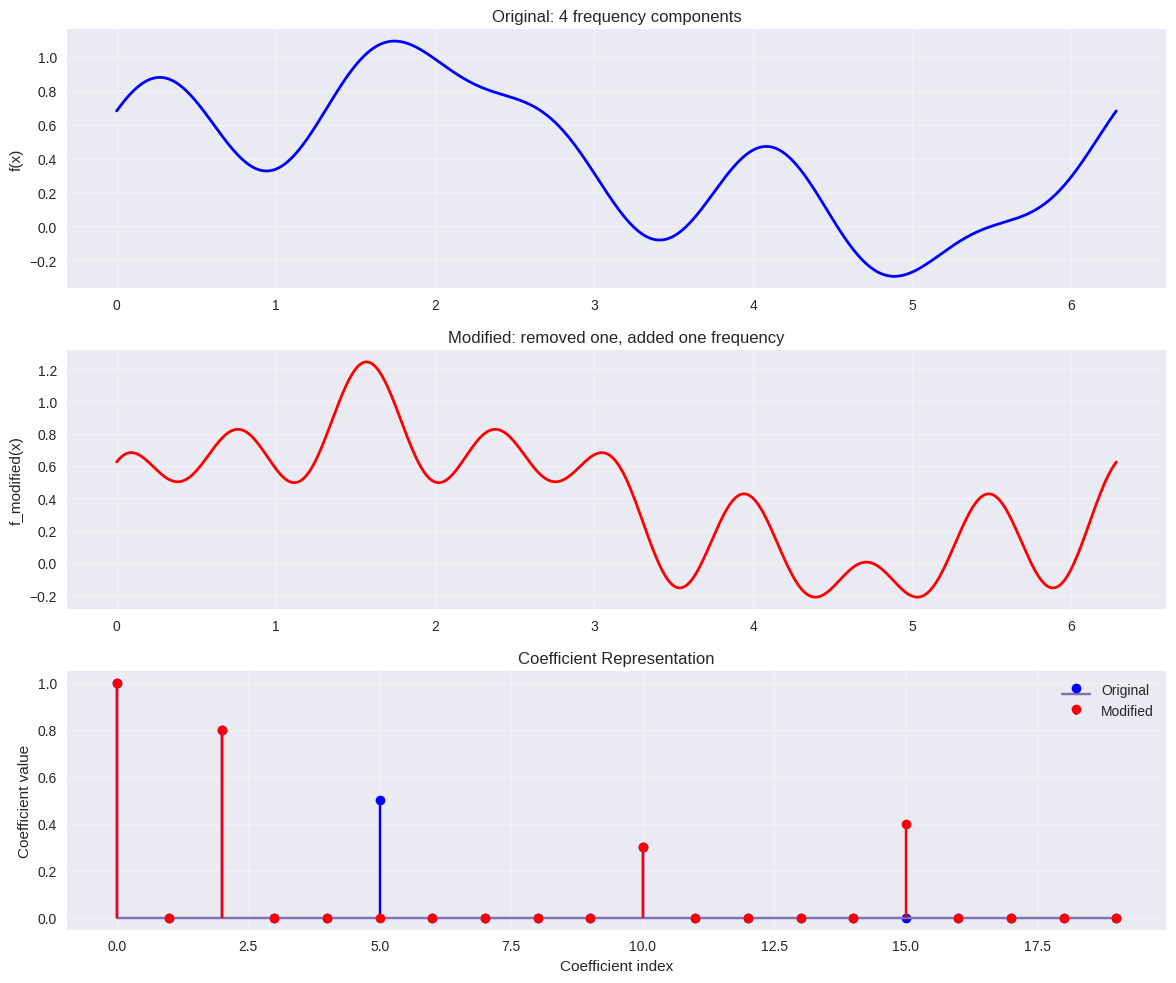


✓ Coefficients provide finite-dimensional representation
✓ Can manipulate frequency content via coefficients
✓ Extraction and reconstruction are consistent


In [15]:
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
space = Lebesgue(20, domain, basis='fourier')

# Create function with specific frequency content
coeffs = np.zeros(20)
coeffs[0] = 1.0   # DC
coeffs[2] = 0.8   # Low frequency
coeffs[5] = 0.5   # Medium frequency
coeffs[10] = 0.3  # High frequency

f = space.from_components(coeffs)

print("Working with Coefficients:")
print("="*60)
print(f"Original coefficients: {coeffs}")
print(f"Non-zero entries: {np.sum(coeffs != 0)}")

# Extract coefficients
extracted = space.to_components(f)
print(f"\nExtracted coefficients match: {np.allclose(coeffs, extracted)}")
print(f"Max difference: {np.max(np.abs(coeffs - extracted)):.2e}")

# Modify coefficients
modified_coeffs = coeffs.copy()
modified_coeffs[5] = 0  # Remove medium frequency
modified_coeffs[15] = 0.4  # Add very high frequency

f_modified = space.from_components(modified_coeffs)

# Visualize
x = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Original function
axes[0].plot(x, f(x), 'b-', linewidth=2)
axes[0].set_ylabel('f(x)')
axes[0].set_title('Original: 4 frequency components')
axes[0].grid(True, alpha=0.3)

# Modified function
axes[1].plot(x, f_modified(x), 'r-', linewidth=2)
axes[1].set_ylabel('f_modified(x)')
axes[1].set_title('Modified: removed one, added one frequency')
axes[1].grid(True, alpha=0.3)

# Coefficient comparison
axes[2].stem(range(20), coeffs, linefmt='b-', markerfmt='bo', label='Original')
axes[2].stem(range(20), modified_coeffs, linefmt='r-', markerfmt='ro',
             basefmt=' ', label='Modified')
axes[2].set_xlabel('Coefficient index')
axes[2].set_ylabel('Coefficient value')
axes[2].set_title('Coefficient Representation')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Coefficients provide finite-dimensional representation")
print("✓ Can manipulate frequency content via coefficients")
print("✓ Extraction and reconstruction are consistent")

## 8. Weighted L² Spaces

### Mathematical Background: Weight Functions

A **weighted L² space** $L^2_w(\Omega)$ uses a **weight function** $w: \Omega \to \mathbb{R}^+$ (positive almost everywhere) to define a modified inner product:

$$
\langle f, g \rangle_w = \int_\Omega f(x) g(x) w(x) \, dx
$$

with induced norm:

$$
\|f\|_{L^2_w} = \sqrt{\langle f, f \rangle_w} = \left( \int_\Omega f(x)^2 w(x) \, dx \right)^{1/2}
$$

### Why Use Weighted Spaces?

1. **Physical significance**: Weight $w(x)$ can represent:
   - Density in mechanics: $w(x) = \rho(x)$
   - Importance weighting in statistics
   - Spatially varying measurement precision: $w(x) = 1/\sigma^2(x)$

2. **Mathematical structure**: Some differential operators are **self-adjoint** in weighted spaces but not in standard $L^2$

3. **Orthogonal polynomials**: Classical orthogonal polynomials (Legendre, Chebyshev, Hermite, Laguerre) arise from different weight functions

### Examples of Weight Functions

- **Uniform**: $w(x) = 1$ (standard $L^2$)
- **Exponential**: $w(x) = e^{-x}$ (Laguerre polynomials on $[0, \infty)$)
- **Gaussian**: $w(x) = e^{-x^2}$ (Hermite polynomials on $\mathbb{R}$)
- **Chebyshev**: $w(x) = 1/\sqrt{1-x^2}$ (Chebyshev polynomials on $[-1, 1]$)

### Impact on Gram Matrix

The Gram matrix in weighted spaces becomes:

$$
G_{ij} = \langle \varphi_i, \varphi_j \rangle_w = \int_\Omega \varphi_i(x) \varphi_j(x) w(x) \, dx
$$

Bases that are orthonormal in standard $L^2$ may **not** be orthonormal in $L^2_w$!

### Core API Usage:

In [16]:
# Create weighted L² space
domain = IntervalDomain(0, 1)

# Standard L²
space_standard = Lebesgue(10, domain, basis='fourier')

# Weighted L² with w(x) = e^(-x)
space_weighted = WeightedLebesgue(10, domain, lambda x: np.exp(-x), basis='fourier')

# Inner products will be different
f = Function(domain, evaluate_callable=lambda x: x**2)
g = Function(domain, evaluate_callable=lambda x: x)

ip_standard = space_standard.project(f).function_domain.integrate(lambda x: f(x) * g(x))
# Weighted inner product computed internally by space_weighted

## 9. Summary: Mathematical vs. Computational Reality

### Mathematical L²
- Elements are **equivalence classes** of functions
- Functions differing on measure-zero sets are equivalent
- Pointwise values are not well-defined (only equivalence class matters)

### Computational L² (intervalinf)

**KEY INSIGHT**: `intervalinf` supports **TWO modes** of working with L² spaces:

#### Mode 1: Function-based (Infinite-dimensional)
- Create: `Lebesgue(0, domain, basis=None)`
- Functions represented via **callables** (evaluation rules)
- Work with the **full infinite-dimensional** $L^2$ space
- No projection needed - functions are what they are!
- Inner products via numerical integration
- Ideal for: general function spaces, non-parametric methods, exact representations

#### Mode 2: Basis-based (Finite-dimensional)
- Create: `Lebesgue(dim, domain, basis='fourier')`
- Functions represented via **coefficient vectors** in a basis
- Work with finite-dimensional subspace $V_n \subset L^2$
- Projection maps infinite-dimensional functions to $V_n$
- Inner products via linear algebra (fast!)
- Ideal for: spectral methods, Galerkin methods, parametric problems

**Both are valid approaches!** Choose based on your application.

### Key Takeaways:

1. **Space structure**: `Lebesgue(dim, domain, basis=...)` where `dim=0, basis=None` for infinite-dimensional
2. **Dual representation**: Functions via callables OR via basis coefficients
3. **Inner product**: $\langle u, v \rangle = \int u(x) v(x) dx$ (computed via integration or linear algebra)
4. **Projection**: Only needed when moving from infinite to finite-dimensional representation
5. **Basis functions are OPTIONAL**: You can work entirely with callables if desired
6. **Equivalence classes**: We represent them with specific callable functions or coefficient vectors

### What's Next:
- **Sobolev Spaces**: Add derivative information and smoothness requirements
- **Operators**: Differential operators, inverse operators, spectral methods
- **Applications**: PDEs, Bayesian inference, inverse problems